In [1]:
from docplex.mp.model import Model
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from qiskit_optimization.converters import QuadraticProgramToQubo
# from qiskit import BasicAer
# from qiskit.algorithms import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.algorithms import CplexOptimizer, MinimumEigenOptimizer
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.applications import BinPacking, Tsp
from brute_force_bpp import *
from qiskit_algorithms import SamplingVQE, NumPyMinimumEigensolver
from vqa_pennylane import *

# from qiskit_algorithms import QAOA


c:\Users\haansari\AppData\Local\Programs\Python\Python313\Lib\site-packages\pennylane\__init__.py:196: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.0 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [2]:
def data_bins(result, weights, n, m, C, simplify=False):
    """
    Organizes the results of the ILP Bin Packing optimization into bins.

    Parameters:
    result (OptimizationResult): Optimization result from the solver.
    weights (list): Weights of each item.
    n (int): Number of items.
    m (int): Maximum possible number of bins.
    C (int): Capacity of each bin.
    simplify (bool): Flag to simplify the output (optional).

    Returns:
    dict: Dictionary with keys "bins", "items", and "index" for bin data.
    """
    # Extract variables dictionary from the result
    variables_dict = result.variables_dict

    # Initialize arrays for decision variables
    x_vars = np.zeros((m, n))
    y_vars = np.zeros(m)

    # Retrieve values from the variables dictionary
    for j in range(m):
        y_vars[j] = variables_dict.get(f"y_{j}", 0)  # Bin j status
        for i in range(n):
            x_vars[j, i] = variables_dict.get(f"x_{i}_{j}", 0)  # Item i in bin j

    # Calculate the weight of items in each bin
    items = x_vars * weights
    bins = y_vars

    return {"bins": bins, "items": items, "index": np.arange(m)}



In [3]:

def plot_bins(result, weights, n, m, C, simplify=False):
    """
    Plots the results of the ILP Bin Packing solution in a bar diagram.

    Parameters:
    result (OptimizationResult): Optimization result from the solver.
    weights (list): Weights of each item.
    n (int): Number of items.
    m (int): Maximum possible number of bins.
    C (int): Capacity of each bin.
    simplify (bool): Flag to simplify the plot (optional).
    """
    res = data_bins(result, weights, n, m, C, simplify)
    plt.figure(figsize=(10, 6))

    # Bin index and initial bar for first item
    ind = res["index"]
    
    # Add first item with label
    suma = res["items"][:, 0]  # Initialize bottom for stacking bars
    plt.bar(ind, suma, label=f"Item 0 ({weights[0]:.2f})")  # label for item 0

    # Stack items in each bin, starting from item 1
    for j in range(1, n):
        plt.bar(ind, res["items"][:, j], bottom=suma, label=f"Item {j} ({weights[j]:.2f})")
        suma += res["items"][:, j]

    # Add a line for the bin capacity
    plt.hlines(C, -0.5, m - 0.5, linestyle="--", color="r", label="Max Capacity (C)")

    plt.xticks(ind)
    plt.xlabel("Bin")
    plt.ylabel("Weight")
    plt.legend()
    plt.title("Bin Packing Solution(MinimumEigenOptimizer)")
    plt.show()


## Formulation

The **Bin Packing Problem (BPP)** is a classic optimization problem where we are given a set of items with specific weights and bins with a fixed capacity. The goal is to pack all items into the minimum number of bins without exceeding the capacity of any bin.

### Problem Definition

- Given $n$ items with weights $w_1, w_2, \ldots, w_n$ and  $m$ bins each of bin capacity $C$.
- Minimize the number of bins used.

### ILP Formulation

**Decision Variables:**
- $x_{ij}$: 1 if item $i$ is in bin $j$, 0 otherwise.
- $y_j$: 1 if bin $j$ is used, 0 otherwise.

**Objective Function:**
$$
\text{Minimize } \sum_{j=1}^{m} y_j
$$
where $m$ is an upper bound on the number of bins.

**Constraints:**
1. Each item must be assigned to exactly one bin:
   $$
   \sum_{j=1}^{m} x_{ij} = 1, \quad \forall i \in \{1, 2, \ldots, n\}
   $$
2. The total weight in each bin cannot exceed its capacity:
   $$
   \sum_{i=1}^{n} w_i x_{ij} \leq C y_j, \quad \forall j \in \{1, 2, \ldots, m\}
   $$
3. Binary Variables:
   $$
   x_{ij} \in \{0, 1\}, \quad y_j \in \{0, 1\}
   $$

### Explanation of Terms
- **Objective Function**: Represents the total number of bins used.
- **Constraint 1**: Ensures each item is placed in exactly one bin.
- **Constraint 2**: Ensures the weight in each bin does not exceed $C$.
- **Binary Constraints**: Ensure $x_{ij}$ and $y_j$ are binary variables.


In [ ]:
def bpp_to_ilp(weights, C):
    # Initialize model
    model = Model(name="Bin Packing Problem")
    n = len(weights)
    m = min_bins(weights, C)
    # Decision Variables
    # x[i, j] = 1 if item i is placed in bin j, 0 otherwise
    x = {(i, j): model.binary_var(name=f"x_{i}_{j}") for i in range(n) for j in range(m)}

    # y[j] = 1 if bin j is used, 0 otherwise
    y = {j: model.binary_var(name=f"y_{j}") for j in range(m)}
    
    # Constraints
    # 1. Each item must be assigned to exactly one bin
    for i in range(n):
        model.add_constraint(model.sum(x[i, j] for j in range(m)) == 1, ctname=f"assign_item_{i}")

    # 2. Total weight in each bin cannot exceed bin capacity
    for j in range(m):
        model.add_constraint(model.sum(weights[i] * x[i, j] for i in range(n)) <= C * y[j], ctname=f"capacity_bin_{j}")
        
    # 3. Enforce that the first item is assigned to the first bin
    model.add_constraint(x[0, 0] == 1, ctname="first_item_first_bin")

    # Objective: Minimize the number of bins used
    model.minimize(model.sum(y[j] for j in range(m)))
    
    return model

In [5]:
# weights = [2,3,1,3]
# C = 5
weights = [3, 2, 3, 4]  # Weights of 4 items

C =  max(weights) +2 # Bin capacity

mod = bpp_to_ilp(weights, C)

mod.prettyprint()
mod.number_of_binary_variables



// This file has been generated by DOcplex
// model name is: Bin Packing Problem
// single vars section
dvar bool x_0_0;
dvar bool x_0_1;
dvar bool x_1_0;
dvar bool x_1_1;
dvar bool x_2_0;
dvar bool x_2_1;
dvar bool x_3_0;
dvar bool x_3_1;
dvar bool y_0;
dvar bool y_1;

minimize
 y_0 + y_1;
 
subject to {
 assign_item_0:
  x_0_0 + x_0_1 == 1;
 assign_item_1:
  x_1_0 + x_1_1 == 1;
 assign_item_2:
  x_2_0 + x_2_1 == 1;
 assign_item_3:
  x_3_0 + x_3_1 == 1;
 capacity_bin_0:
  3 x_0_0 + 2 x_1_0 + 3 x_2_0 + 4 x_3_0 <= 6 y_0;
 capacity_bin_1:
  3 x_0_1 + 2 x_1_1 + 3 x_2_1 + 4 x_3_1 <= 6 y_1;
 first_item_first_bin:
  x_0_0 == 1;

}


10

### Objective Function

Minimize:

$$
\sum_{i=1}^{m} y_i + \alpha \left[ - \sum_{i=1}^{m} \left( C y_i - \sum_{j=1}^{n} w_j x_{ij} \right) + \left( \sum_{i=1}^{m} \left( C y_i - \sum_{j=1}^{n} w_j x_{ij} \right) \right)^2 \right]
$$

Where:
- $y_i$ is a binary variable indicating whether bin $i$ is used (1) or not (0).
- $x_{ij}$ is a binary variable indicating whether item $j$ is assigned to bin $i$.

### Subject to:

#### 1. Assignment Constraint:
Each item must be assigned to exactly one bin:

$$
\sum_{i=1}^{m} x_{ij} = 1 \quad \forall j = 1, \dots, n
$$

#### 2. Capacity Constraint:
The total weight in each bin cannot exceed its capacity if the bin is used:

$$
\sum_{j=1}^{n} w_j x_{ij} \leq C y_i \quad \forall i = 1, \dots, m
$$

#### 3. Binary Constraints:

For the assignment variables:

$$
x_{ij} \in \{0, 1\} \quad \forall i = 1, \dots, m \quad \text{and} \quad j = 1, \dots, n
$$

For the bin usage variables:

$$
y_i \in \{0, 1\} \quad \forall i = 1, \dots, m
$$


In [17]:
def ilp_to_qubo(docplex_model):
    """
    Converts a given ILP Docplex model to a QUBO model.

    Parameters:
    docplex_model: Model
        A Docplex model representing an ILP problem.

    Returns:
    qubo: Quadratic """

    qp = from_docplex_mp(docplex_model)
    qp2qubo = QuadraticProgramToQubo()
    qubo = qp2qubo.convert(qp)
    # print(qubo.prettyprint())
    return qubo

In [21]:

qresult = ilp_to_qubo(mod)

qresult.get_num_binary_vars()

qresult.get_linear_constraint

# qresult.to_ising()

# qresult.get_num_integer_vars()

# print(qresult.prettyprint())


qp = from_docplex_mp(mod)

qresult.get_num_binary_vars()

16

In [18]:

# my model 
mod1 = bpp_to_ilp(weights, C)

mod1_qubo = ilp_to_qubo(mod1)


# qubo = qp2qubo.convert(mod1)
qubitOp, offset = mod1_qubo.to_ising()

print(qubitOp.num_qubits)
exact = MinimumEigenOptimizer(NumPyMinimumEigensolver())
result = exact.solve(mod1_qubo)
print(result.prettyprint())

result._variable_names


# result._min_eigen_solver_result._eigenstate

mod1_qubo.binary_var()


16
objective function value: 2.0
variable values: x_0_0=1.0, x_0_1=0.0, x_1_0=0.0, x_1_1=1.0, x_2_0=1.0, x_2_1=0.0, x_3_0=0.0, x_3_1=1.0, y_0=1.0, y_1=1.0, capacity_bin_0@int_slack@0=0.0, capacity_bin_0@int_slack@1=0.0, capacity_bin_0@int_slack@2=0.0, capacity_bin_1@int_slack@0=0.0, capacity_bin_1@int_slack@1=0.0, capacity_bin_1@int_slack@2=0.0
status: SUCCESS


<Variable: x16 (binary)>

### VQA Approach

In [18]:
# solving Quadratic Program using exact classical eigensolver

ee = NumPyMinimumEigensolver()
result = ee.compute_minimum_eigenvalue(qubitOp)


data = result.eigenstate
rounded_statevector = np.round(data.data, decimals=1)
# def VQA_qubo(qubo_model):

#     qubo_model.to_ising()

print(rounded_statevector)

[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]


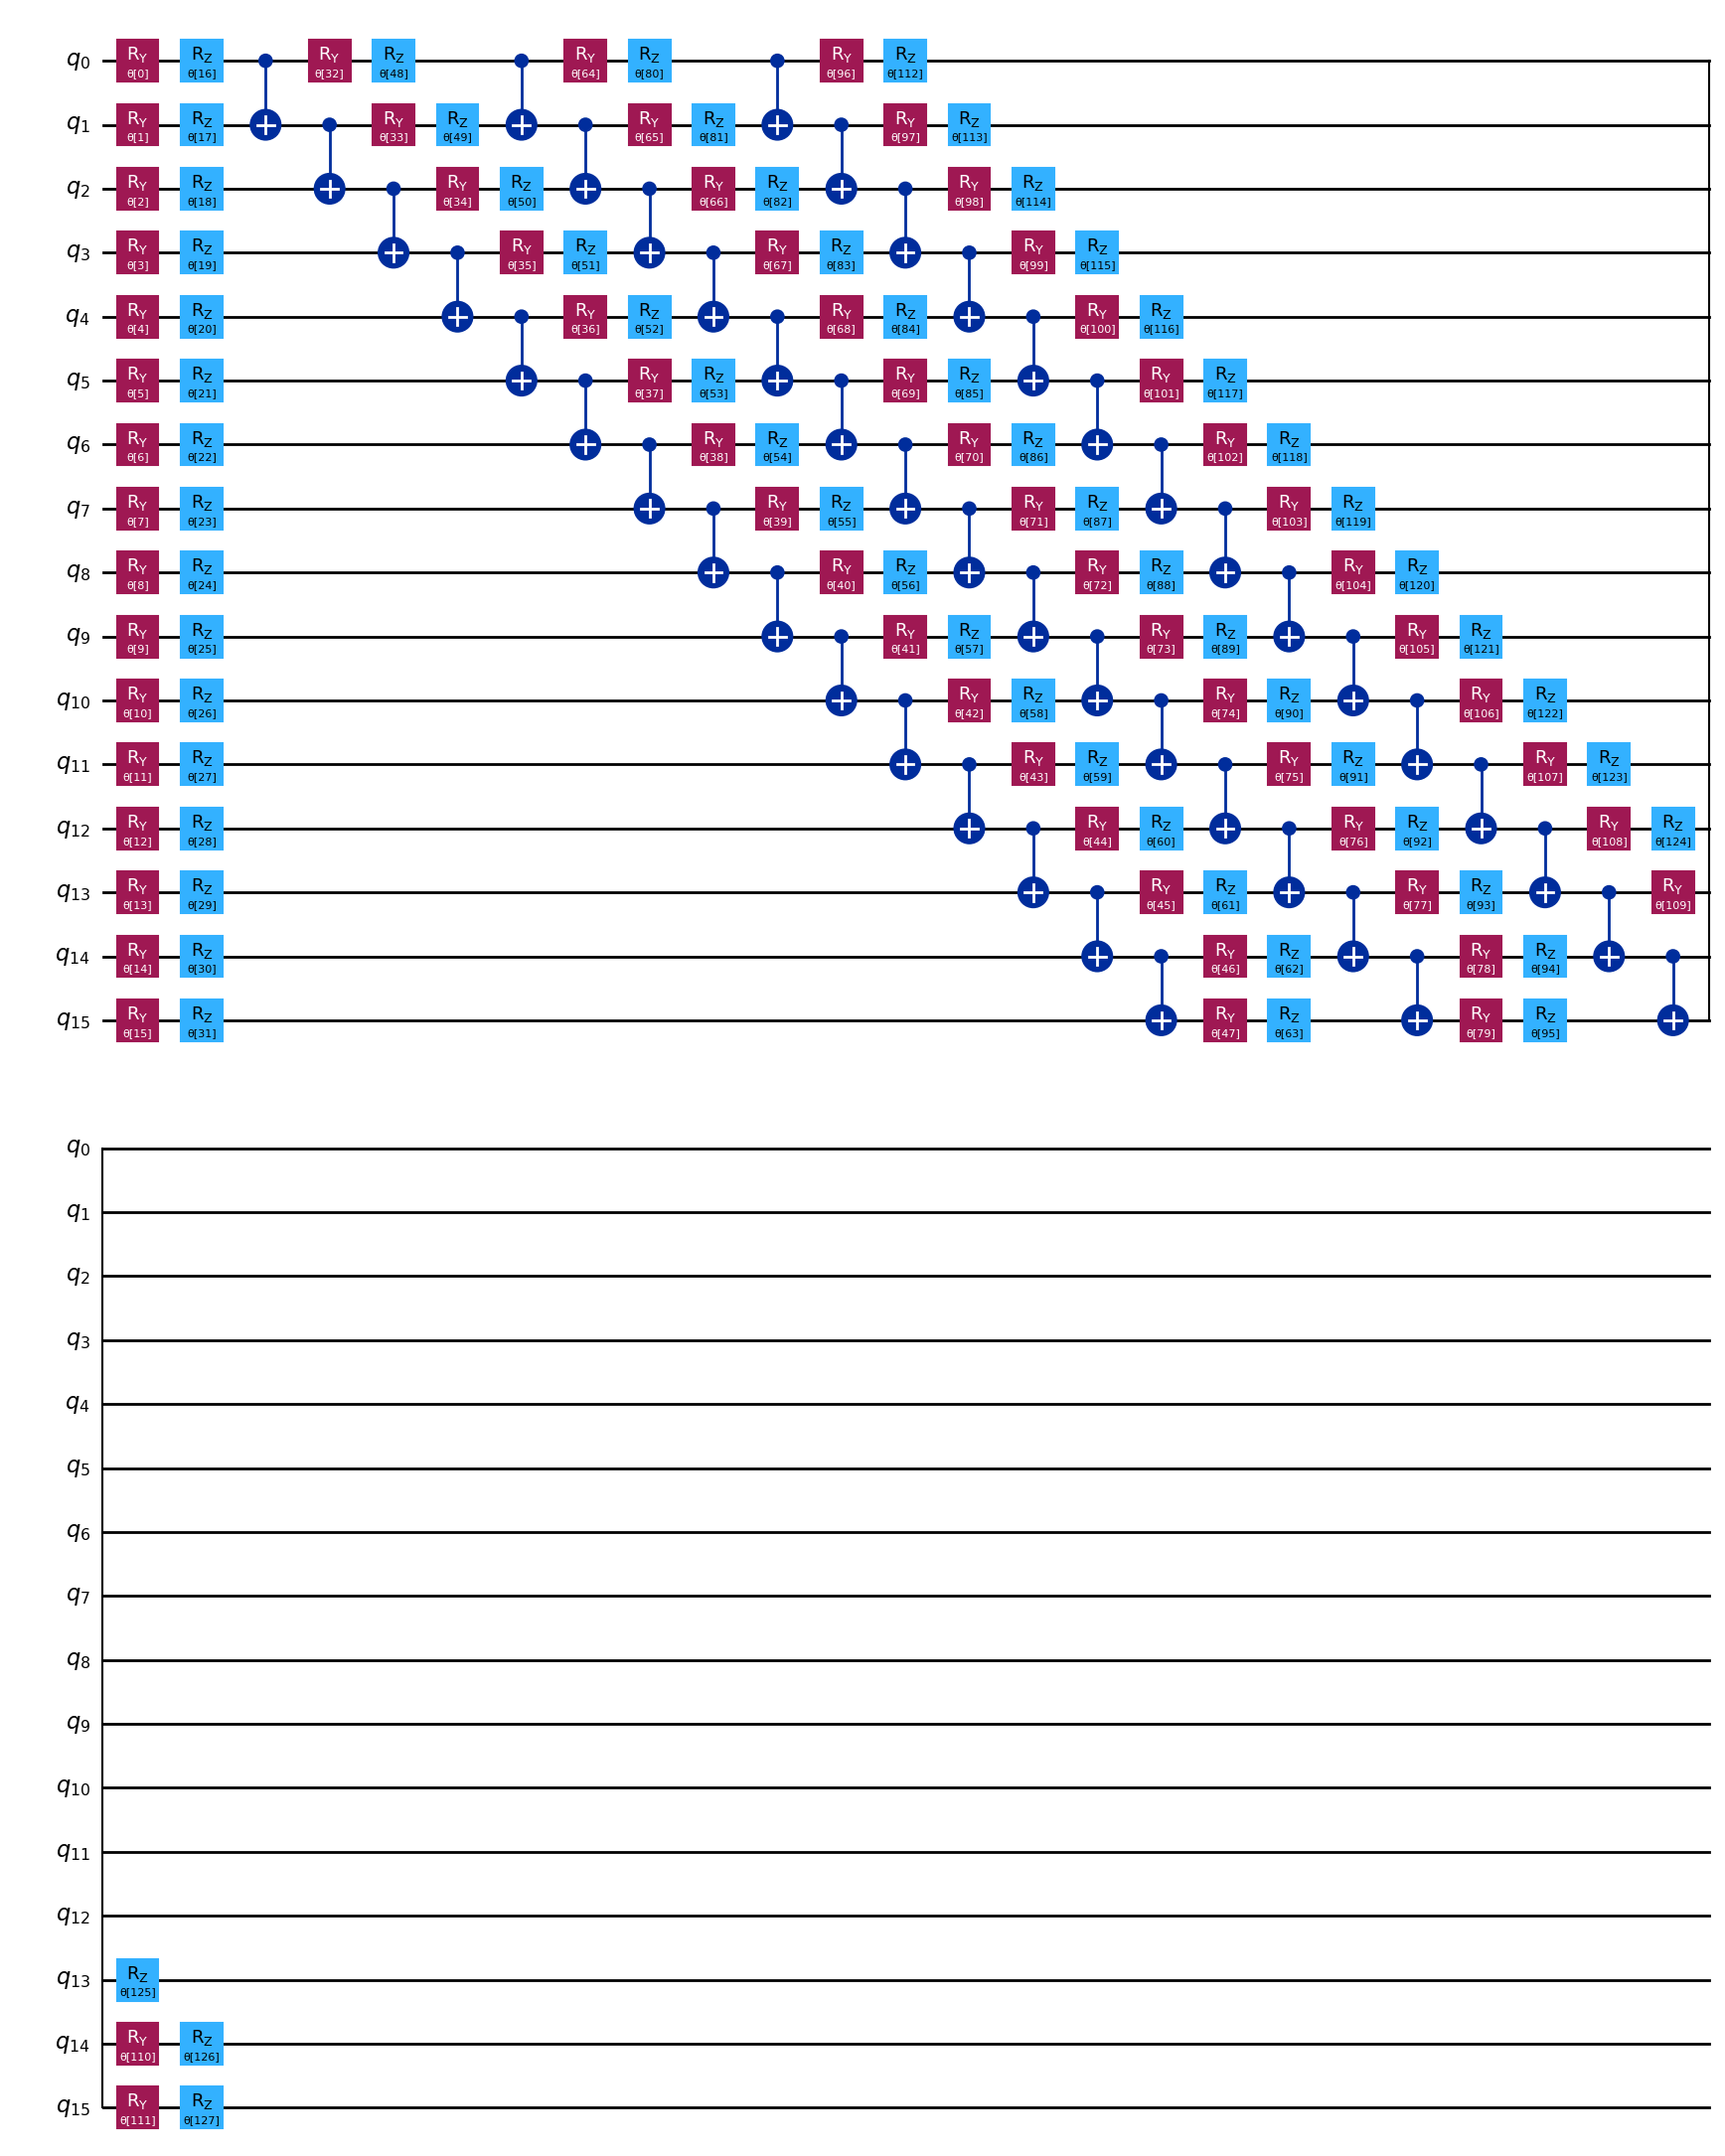

In [24]:
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms.optimizers import COBYLA

optimizer = COBYLA(maxiter=100)

num_qubits = qubitOp.num_qubits
ansatz = EfficientSU2(num_qubits, entanglement='linear')

ansatz = ansatz.decompose()
ansatz.draw(output="mpl")

# num_qubits

In [21]:
# from qiskit_algorithms import VQE

# vqe = VQE(ansatz, optimizer, quantum_instance=quantum_instance)
# result = vqe.compute_minimum_eigenvalue(qubitOp)

# VQE

In [22]:
# useful additional packages
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

from qiskit.circuit.library import TwoLocal
from qiskit_optimization.applications import Maxcut, Tsp
from qiskit_algorithms import SamplingVQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SPSA
from qiskit_algorithms.utils import algorithm_globals
from qiskit.primitives import Sampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer

In [23]:
algorithm_globals.random_seed = 123
seed = 10598

In [ ]:
# construct SamplingVQE
optimizer = SPSA(maxiter=300)
ry = TwoLocal(qubitOp.num_qubits, "ry", "cz", reps=5, entanglement="linear")
vqe = SamplingVQE(sampler=Sampler(), ansatz=ry, optimizer=optimizer)

# run SamplingVQE
resultvqe = vqe.compute_minimum_eigenvalue(qubitOp)

# print results
print("energy:", resultvqe.eigenvalue.real)
print("time:", resultvqe.optimizer_time)
print("max-cut objective:", resultvqe.eigenvalue.real + offset)

In [ ]:
from qiskit.primitives import Sampler
from qiskit.quantum_info import Pauli
from qiskit.result import QuasiDistribution

from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA

from qiskit_algorithms.utils import algorithm_globals

sampler = Sampler()
def bitfield(n, L):
    result = np.binary_repr(n, L)
    return [int(digit) for digit in result]  # [2:] to chop off the "0b" part


def sample_most_likely(state_vector):
    """Compute the most likely binary string from state vector.
    Args:
        state_vector: State vector or quasi-distribution.

    Returns:
        Binary string as an array of ints.
    """
    if isinstance(state_vector, QuasiDistribution):
        values = list(state_vector.values())
    else:
        values = state_vector
    n = int(np.log2(len(values)))
    k = np.argmax(np.abs(values))
    x = bitfield(k, n)
    x.reverse()
    return np.asarray(x)

x = sample_most_likely(result.eigenstate)

print(x)

[1 0 0 1 1 0 0 1 1 1 0 0 0 0 0 0]


In [ ]:
# create minimum eigen optimizer based on SamplingVQE
vqe_optimizer = MinimumEigenOptimizer(vqe)

# solve quadratic program
resultvqeo = vqe_optimizer.solve(mod1)
# print(resultvqeo.prettyprint())

KeyboardInterrupt: 

In [ ]:
result

TypeError: SamplingVQE._build_sampling_vqe_result() missing 6 required positional arguments: 'ansatz', 'optimizer_result', 'aux_operators_evaluated', 'best_measurement', 'final_state', and 'optimizer_time'

### QAOA Approach

In [ ]:
from qiskit.circuit.library import QAOAAnsatz

max_ansatz = QAOAAnsatz(qubitOp, reps=2)
# max_ansatz.decompose(reps=3).draw("mpl")

In [ ]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (Estimator): Estimator primitive instance

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs
#    cost = estimator.run(ansatz, hamiltonian, parameter_values=params).result().values[0]
    return cost

create set an initial set of random parameters:

In [ ]:
x0 = 2 * np.pi * np.random.rand(max_ansatz.num_parameters)
print(x0)

[5.66988418 3.01680936 6.02968676 3.29605462]


In [ ]:
from qiskit.primitives import StatevectorSampler, StatevectorEstimator

estimator = StatevectorEstimator()
cost = cost_func(x0, max_ansatz, qubitOp, estimator)
print(cost)

-33.080735620762326


### And run our minimization routine:

The solution vector of parameter angles ( x ), when plugged into the ansatz circuit, yields the graph partitioning that we were looking for.




In [ ]:
# SciPy minimizer routine
from scipy.optimize import minimize
result = minimize(cost_func, x0, args=(max_ansatz, qubitOp, estimator), method="COBYLA")

In [ ]:
result.

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -50.81185440486918
       x: [ 5.702e+00  2.911e+00  6.517e+00  4.313e+00]
    nfev: 48
   maxcv: 0.0

In [ ]:
eigenvalue = cost_func(result.x, max_ansatz, qubitOp, estimator)
print(f"""Eigenvalue: {eigenvalue}""")
print(f"""Max-Cut Objective: {eigenvalue + offset}""")

Eigenvalue: -50.81185440486918
Max-Cut Objective: 305.68814559513083


In [ ]:
from qiskit.result import QuasiDistribution
from qiskit.primitives import StatevectorSampler
sampler = StatevectorSampler()

# Assign solution parameters to ansatz
qc = max_ansatz.assign_parameters(result.x)

# Add measurements to our circuit
qc.measure_all()

# Sample ansatz at optimal parameters
#samp_dist = sampler.run(qc).result().quasi_dists[0]

shots = 10000000
job = sampler.run([qc], shots = shots)

In [ ]:
data_pub = job.result()[0].data
bitstrings = data_pub.meas.get_bitstrings()
counts = data_pub.meas.get_counts()

In [ ]:
from collections import Counter

# Use Counter to count the frequency of each item
count_freq = Counter(counts)

# Get the most common counts
most_common = count_freq.most_common(1)  # Gets the most common count
print("Most frequent count:", most_common)

Most frequent count: [('0010010011000000', 11813)]
